In [295]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from scipy.stats import shapiro
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# Import KNN classifier
from sklearn.neighbors import KNeighborsClassifier

# Import Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score

In [296]:
df= pd.read_csv('diabetes.csv')

In [297]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [298]:
df.shape

(768, 9)

In [299]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [300]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [301]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [302]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [303]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [304]:
for col in df.select_dtypes(include = ["int64", "float64"]).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1-1.5*iqr
    upper = q3+1.5*iqr
    df[col]= df[col].clip(lower, upper)

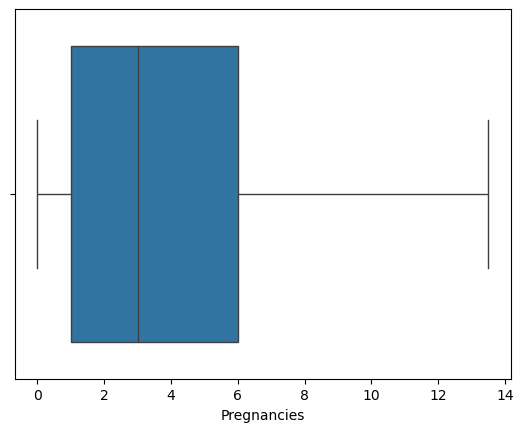

In [305]:
sns.boxplot(x= df['Pregnancies'])
plt.show()

In [306]:
# df.drop_duplicates(inplace=True)

In [307]:
df.shape

(768, 9)

TRAIN TEST SPLIT

In [308]:
X = df.drop("Outcome", axis =1)
X.shape

(768, 8)

In [309]:
y = df['Outcome']
y.shape

(768,)

In [310]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [311]:
X_train.shape

(614, 8)

In [312]:
X_test.shape

(154, 8)

In [313]:
smote = SMOTE()

In [314]:
X_train , y_train = smote.fit_resample(X_train, y_train)

In [315]:
X_train.shape

(802, 8)

In [316]:
y_train.shape

(802,)

In [317]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [318]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.837240,121.136230,70.684896,20.511719,73.652669,32.125065,0.458914,33.199870,0.348958
std,3.344157,31.187468,14.197239,15.844744,93.576029,7.049584,0.285596,11.628404,0.476951
min,0.000000,37.125000,35.000000,0.000000,0.000000,13.350000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,13.500000,199.000000,107.000000,80.000000,318.125000,50.550000,1.200000,66.500000,1.000000


In [319]:
df.median()

Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
SkinThickness                23.0000
Insulin                      30.5000
BMI                          32.0000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Outcome                       0.0000
dtype: float64

In [320]:
# model = LogisticRegression()
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)


In [321]:
# accuracy= accuracy_score(y_test,y_pred)
# accuracy

In [322]:
# precision =precision_score(y_test, y_pred)
# precision

In [323]:
# f1_score = f1_score(y_test, y_pred)
# f1_score

In [324]:
# models = {'lr':LogisticRegression(),
#          'dtc':DecisionTreeClassifier(),
#          'rfc':RandomForestClassifier(),
#          'knc':KNeighborsClassifier(),
#          'nb':GaussianNB()}
# for name, model in models.items():
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     acc= accuracy_score(y_test,y_pred)
#     precision =precision_score(y_test, y_pred)
#     score = f1_score(y_test, y_pred)
#     print(name, acc, precision)
    

In [325]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [326]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()

# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [327]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [328]:
!pip install xgboost

In [329]:
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import recall_score

In [330]:
# models = {'lr':LogisticRegression(),
#          'dtc':DecisionTreeClassifier(),
#          'rfc':RandomForestClassifier(),
#          'knc':KNeighborsClassifier(),
#          'nb':GaussianNB(),
#          'adb': AdaBoostClassifier(),
#          'xgb': XGBClassifier()}
# for name, model in models.items():
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     acc= accuracy_score(y_test,y_pred)
#     precision =precision_score(y_test, y_pred)
#     score = f1_score(y_test, y_pred)
#     recall = recall_score 
#     # print(name, acc, precision, score)
#     print(f"Model: {name}, Accuracy: {acc}, Precision: {precision}, F1_score: {score}, Recall: {recall}")

In [331]:
# plt.figure(figure= (10,6))
# sns.heatmap(df.corr(),annot = True)
# plt.show()

In [332]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc= accuracy_score(y_test,y_pred)
acc

0.7857142857142857

In [338]:
input_data =(1,89,66,23,94,28.1,0.167,21)
np_df = np.asarray(input_data)
np_df_reshaped = np_df.reshape(1,-1)
prediction = model.predict(np_df_reshaped)
prediction

array([1], dtype=int64)

MODEL SAVING

In [339]:
import joblib

In [340]:
joblib.dump(model,'diabetes_prediction_model.pkl')

['diabetes_prediction_model.pkl']

HYPERPARAMETER TUNING

In [ ]:
# params = {
#     "C":[0.01,0.1,1,10,100,500,1000],
#     "penalty":["9","10","11","l2","13"],
#     "solver":["liblinear"]
# }
# lr= LogisticRegression()

# grid = GridSearchCV(
#         estimator=lr,
#         param_grid=params,
#         cv=5
# )

# grid.fit(X_train,y_train)
# print(grid.best_params_)